# Day 4: MachineLearning_for_Data_Engineering

#Linear Regression

In [67]:
import pandas as pd
df= pd.read_csv("/content/SOCR-HeightWeight.csv")

In [68]:
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


**x and y selection**

In [69]:
x=df[["Height(Inches)"]]
y=df[["Weight(Pounds)"]]

# Data Cleaning
**Check for Null values**

In [70]:
print(f'Null values in x (Height): {x.isnull().sum()}')

Null values in x (Height): Height(Inches)    0
dtype: int64


In [71]:
print(f'Null values in y (Weight): {y.isnull().sum()}')

Null values in y (Weight): Weight(Pounds)    0
dtype: int64


**Split data into training data and testing data**

In [72]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=0)
#20% data for testing
#80% for training


In [73]:
from sklearn.linear_model import LinearRegression  #Import :Linear Regression model
model = LinearRegression()   #creating a Linear Regression model object and storing it in a variable called model
model.fit(x_train,y_train)   #learns the relationship between input and output (train).
y_pred =model.predict(x_test) #makes predictions

In [74]:
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score    #import evaluation metrics
mean_absolute_error(y_test, y_pred)


8.187041886060046

#  Mean Absolute Error (MAE)

##  Overview
To measure the average magnitude of errors in a set of predictions, without considering their direction.

It tells us how far predictions are from actual values on average.

---

##  Formula

MAE is calculated as:

MAE = (1/n) * Σ |y_actual - y_predicted|

---

##  Intuition
- It calculates the **average absolute difference** between actual and predicted values.
- Ignores whether the error is positive or negative.
- Focuses only on **how big the error is**.



In [75]:
mean_squared_error(y_test, y_pred)


105.05298919282605

#  R² Score (Coefficient of Determination)

##  Overview
R² Score is a regression evaluation metric used to measure how well a machine learning model explains the variation in the target variable.

It shows how close the predicted values are to the actual values.

---

##  Formula

R² = 1 - ( Σ (y_actual - y_predicted)² / Σ (y_actual - y_mean)² )

---

##  Intuition
- Compares your model with a **baseline model (mean prediction)**
- Tells how much variance in data is explained by the model
- Higher value = better model fit



In [76]:
r2_score(y_test,y_pred)

0.2588330299924131

#  Model Saving using Joblib

## Overview
Joblib is used to save a trained machine learning model so that it can be reused later without retraining.


In [77]:
import joblib

joblib.dump(model,'linear.pkl')

['linear.pkl']

In [78]:
df=pd.read_csv('data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [79]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [80]:
df.dropna()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [81]:

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

# DecisionTreeRegressor

In [83]:
dt_model=DecisionTreeRegressor(
    max_depth=5,#level in a tree
    random_state=42
)
model=DecisionTreeRegressor()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
mean_squared_error(y_test,y_pred)

198.10901773066553

In [84]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_pred)

11.281221403333333

# RandomForestRegressor

In [85]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Practice Questions

## 1. What is the difference between supervised and unsupervised ML? Give one real-world example of each.

**Supervised Learning:** Uses labeled data to make predictions.
- Example: Predicting student programming scores.

**Unsupervised Learning:** Uses unlabeled data to find patterns.
- Example: Grouping students based on performance using clustering.

---

## 2. Why can't you feed raw student_performance.csv directly into a Scikit-learn model without feature engineering?

Raw data may contain irrelevant columns and lacks meaningful derived features. Feature engineering improves model accuracy and helps the model learn better patterns.

---

## 3. What does train_test_split() do and why is it necessary? What problem does it prevent?

`train_test_split()` divides data into training and testing sets.

**Why necessary?**
- Train the model on one dataset.
- Evaluate it on unseen data.

**Prevents:** Overfitting and biased evaluation.

---

## 4. A model has R² = 0.92 on training data but R² = 0.41 on test data. What is this problem called and how do you fix it?

**Problem:** Overfitting

**Solutions:**
- Collect more data
- Feature selection
- Hyperparameter tuning
- Cross-validation

---

## 5. Write code to train a Random Forest model and print its R² score on test data.

```python
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, pred))
```

---

## 6. In the Data Engineering → ML pipeline, which step from Days 1–4 is most critical for model quality? Why?

**Feature Engineering**

Feature engineering is the most critical step because the quality of features directly impacts model performance. Good features help the model learn meaningful patterns and improve prediction accuracy.

---

# PHASE 1 FINAL MINI PROJECT

##Project Option 1: Student Analytics System
Complete end-to-end pipeline using student_performance.csv

`CSV → SQL Analysis → Visualization → ML Prediction → Report`

In [86]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Exploration

In [87]:
import pandas as pd

df = pd.read_csv('student_performance.csv')

print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print("-"*30)
print(f"[1] Columns: {df.columns.tolist()}")

print("\n[2] Missing Values:")
print("-"*30)
print(df.isnull().sum())

print(f"\n[3] Total Missing Values: {df.isnull().sum().sum()}")
print("-"*30)

print("\n[4] Dataset Information:")
print("-"*30)
print(df.info())

print("\n[5] First 5 Rows:")
print("-"*30)
display(df.head())

print(f"\n[6] Duplicate rows : {df.duplicated().sum()}")
print("-"*30)

print("\n[7] Datatypes for each column")
print("-"*30)
print(df.dtypes)

Dataset loaded: 30 students, 13 columns
------------------------------
[1] Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

[2] Missing Values:
------------------------------
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64

[3] Total Missing Values: 0
------------------------------

[4] Dataset Information:
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 -------------- 

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023



[6] Duplicate rows : 0
------------------------------

[7] Datatypes for each column
------------------------------
student_id                int64
name                     object
age                       int64
gender                   object
department               object
semester                  int64
math_score                int64
science_score             int64
english_score             int64
programming_score         int64
attendance_percentage     int64
city                     object
admission_year            int64
dtype: object


## 2. SQLite Database Creation & SQL Analysis

In [88]:

conn = sqlite3.connect('students.db')

df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

print("Database and table created successfully.")

Database and table created successfully.


In [89]:
def run_query(sql,description=""):
   if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'='*55}")
   result=pd.read_sql_query(sql, conn)
   print(result.to_string(index=False))
   return result

In [90]:
# Top 5 Students by Total Score

query1 = """
SELECT
    name, department,
    (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 5;
"""

top_students = run_query(query1,"Top 5 Students by Total Score")


Top 5 Students by Total Score
          name       department  total_score
    Ananya Das Computer Science          371
   Tanvi Mehta Computer Science          367
Akanksha Yadav Computer Science          365
    Arjun Nair Computer Science          356
   Divya Singh Computer Science          356


In [91]:
# Department wise Average Score
query2 = """
SELECT
    department,
    ROUND(AVG(math_score + science_score + english_score + programming_score)/4,2) AS avg_score
FROM students
GROUP BY department
ORDER BY avg_score DESC;
"""

dept_avg = run_query(query2,"Department-wise Average Score")


Department-wise Average Score
      department  avg_score
Computer Science      85.04
     Electronics      69.38
      Mechanical      66.83
           Civil      58.95


In [92]:
# Department wise Average Attendance
query3 = """
SELECT
    department,
    ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
ORDER BY avg_attendance DESC;
"""

attendance = run_query(query3,"Department-wise Average Attendance")


Department-wise Average Attendance
      department  avg_attendance
Computer Science           90.69
      Mechanical           83.50
     Electronics           80.33
           Civil           74.60


In [93]:
# Top 5 Students by Attendance

query4 = """
SELECT
    name,department,attendance_percentage
FROM students
ORDER BY attendance_percentage DESC
LIMIT 5;
"""

top_attendance = run_query(query4,"Top 5 Students by Attendance")


Top 5 Students by Attendance
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95


In [94]:
# Department wise Programming Performance

query5 = """
SELECT
    department,
    ROUND(AVG(programming_score),2) AS avg_programming_score
FROM students
GROUP BY department
ORDER BY avg_programming_score DESC;
"""

programming_perf = run_query(query5,"Department-wise Programming Performance")


Department-wise Programming Performance
      department  avg_programming_score
Computer Science                  89.23
     Electronics                  61.50
      Mechanical                  49.33
           Civil                  40.60


In [95]:
# Programming Performance by Gender
query6 = """
SELECT
    gender,
    ROUND(AVG(programming_score),2) AS avg_programming_score
FROM students
GROUP BY gender;
"""

gender_perf = run_query(query6,"Programming Performance by Gender")


Programming Performance by Gender
gender  avg_programming_score
Female                   70.2
  Male                   65.0


## 3. Feature Engineering

In [96]:
df['total_score'] = (df['math_score']+df['science_score']+df['english_score']+df['programming_score'])

In [97]:
df['average_score'] = df['total_score'] / 4

In [98]:
def performance(score):
    if score >= 85:
        return 'Excellent'
    elif score >= 70:
        return 'Good'
    elif score >= 50:
        return 'Average'
    else:
        return 'Poor'

df['performance_category'] = df['average_score'].apply(performance)

In [99]:
df[['name','total_score','average_score','performance_category']].head()

,name,total_score,average_score,performance_category
0,Aarav Sharma,326,81.50,Good
1,Priya Patel,325,81.25,Good
2,Rohit Verma,255,63.75,Average
3,Sneha Reddy,273,68.25,Average
4,Arjun Nair,356,89.00,Excellent


## 4. Visualization

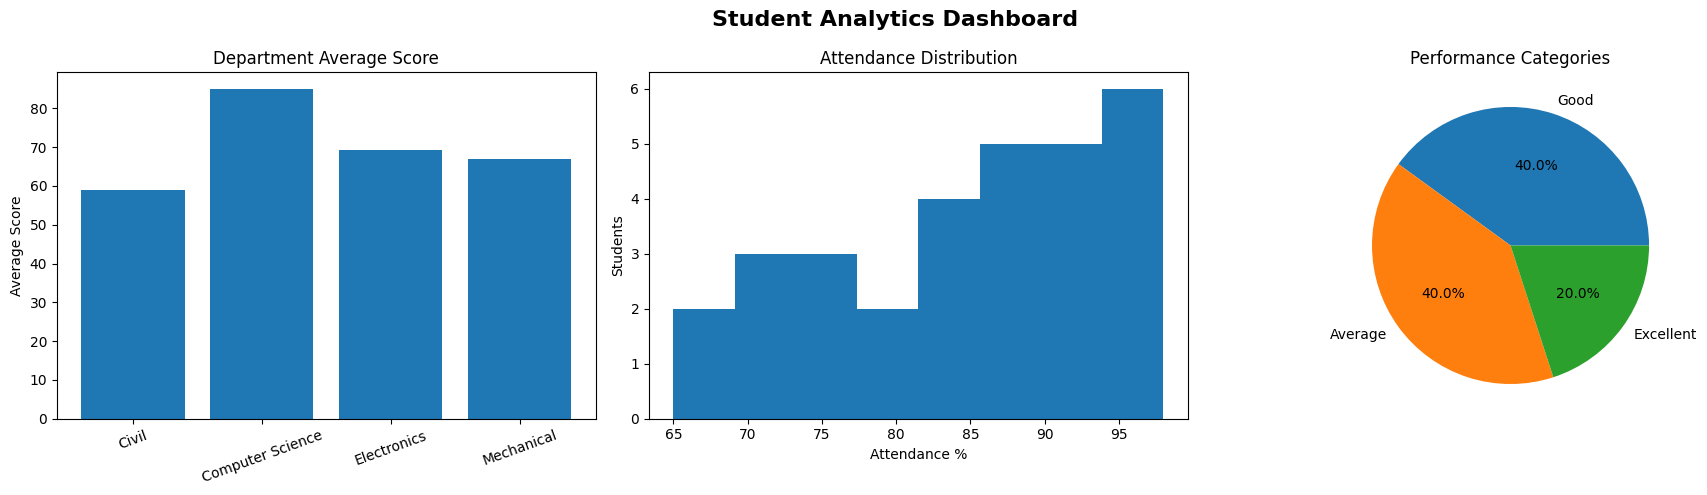

In [100]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Department-wise Average Score
dept_avg = df.groupby('department')['average_score'].mean()

axes[0].bar(
    dept_avg.index,
    dept_avg.values
)
axes[0].set_title('Department Average Score')
axes[0].set_ylabel('Average Score')
axes[0].tick_params(axis='x', rotation=20)

# Chart 2: Attendance Distribution
axes[1].hist(
    df['attendance_percentage'],
    bins=8
)
axes[1].set_title('Attendance Distribution')
axes[1].set_xlabel('Attendance %')
axes[1].set_ylabel('Students')

# Chart 3: Performance Category Distribution
performance_counts = df['performance_category'].value_counts()

axes[2].pie(
    performance_counts,
    labels=performance_counts.index,
    autopct='%1.1f%%'
)
axes[2].set_title('Performance Categories')

plt.suptitle(
    'Student Analytics Dashboard',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## 5. Machine Learning Prediction

In [101]:
X = df[['age','semester','math_score','science_score','english_score','attendance_percentage']]
y = df['programming_score']

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


In [103]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100,random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [104]:
predictions = model.predict(X_test)
results = pd.DataFrame({'Actual': y_test,'Predicted': predictions})
results

,Actual,Predicted
27,39,57.53
15,69,90.57
23,53,73.48
17,92,93.18
8,45,51.49
9,97,95.04


In [105]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"R²  : {r2:.2f}")

MAE : 11.70
MSE : 212.57
R²  : 0.57


In [106]:
print("\n" + "="*60)
print("BUSINESS SUMMARY & INSIGHTS")
print("="*60)

print("• Computer Science is the best performing department with an average score of 85.04.")
print("• Civil department recorded the lowest average score at 58.95.")
print("• Ananya Das is the top-performing student with a total score of 371.")
print("• All Top 5 students belong to the Computer Science department.")
print("• Computer Science also has the highest average attendance (90.69%).")
print("• Civil department has the lowest average attendance (74.60%).")
print("• Programming performance is highest in Computer Science (89.23) and lowest in Civil (40.60).")
print("• Female students achieved a slightly higher average Programming score (70.2) than male students (65.0).")
print("• Higher attendance is associated with better academic performance across departments.")
print("• Random Forest achieved an R² score of 0.57, showing moderate predictive capability.")


BUSINESS SUMMARY & INSIGHTS
• Computer Science is the best performing department with an average score of 85.04.
• Civil department recorded the lowest average score at 58.95.
• Ananya Das is the top-performing student with a total score of 371.
• All Top 5 students belong to the Computer Science department.
• Computer Science also has the highest average attendance (90.69%).
• Civil department has the lowest average attendance (74.60%).
• Programming performance is highest in Computer Science (89.23) and lowest in Civil (40.60).
• Female students achieved a slightly higher average Programming score (70.2) than male students (65.0).
• Higher attendance is associated with better academic performance across departments.
• Random Forest achieved an R² score of 0.57, showing moderate predictive capability.


--END OF MINIPROJECT DAY-5--